Trials in journal : 200
  completed       : 194
  running         : 0
Best score so far : 0.1230  (trial #162)
Best params       :
  units          = 1500
  L              = 1
  connectivity   = 0.1
  sr             = 0.85
  lr             = 0.05
  input_scaling  = 1.85
  bias_scaling   = 0.1
  tau            = 1
  noise_sigma    = 0.006


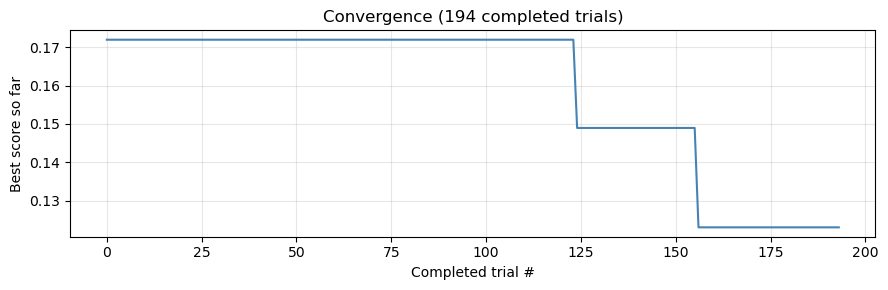

In [1]:
import tm_esn_optuna_v2 as study

study.status()

In [2]:
study.request_stop()
# Wait ~1 minute for both terminals to finish their current trials and exit cleanly. 

Stop flag written: ./tm_esn_stop_flag
Workers will exit after their current trial completes.
Wait until each terminal prints 'Elapsed: ...s' before calling
final_report() to get the validated best model.



OPTUNA STUDY COMPLETE
Trials run        : 166
Best score        : 0.123039
Best parameters   :
  units              = 1500
  L                  = 1
  connectivity       = 0.1
  sr                 = 0.85
  lr                 = 0.05
  input_scaling      = 1.85
  bias_scaling       = 0.1
  tau                = 1
  noise_sigma        = 0.006
Best ridge        : 1e-09
Best NRMSE(short) : 0.012153
Best spike pen    : 0.094961
Best ISI dist     : 0.211351

Top 10 trials:
Rank  units     sr     lr   in_sc   bias   tau    L   noise      ridge     score
-----------------------------------------------------------------------------------------------
   1   1500   0.85   0.05    1.85   0.10     1    1   0.006    1.0e-09    0.1230
   2    750   1.02   0.07    1.60   0.10    16    4   0.002    1.0e-07    0.1489
   3    750   1.12   0.29    2.00   0.40    24    3   0.004    1.0e-06    0.1624
   4   1000   0.82   0.13    1.30   1.00    12    6   0.002    1.0e-10    0.1654
   5   1000   0.85   0.19    

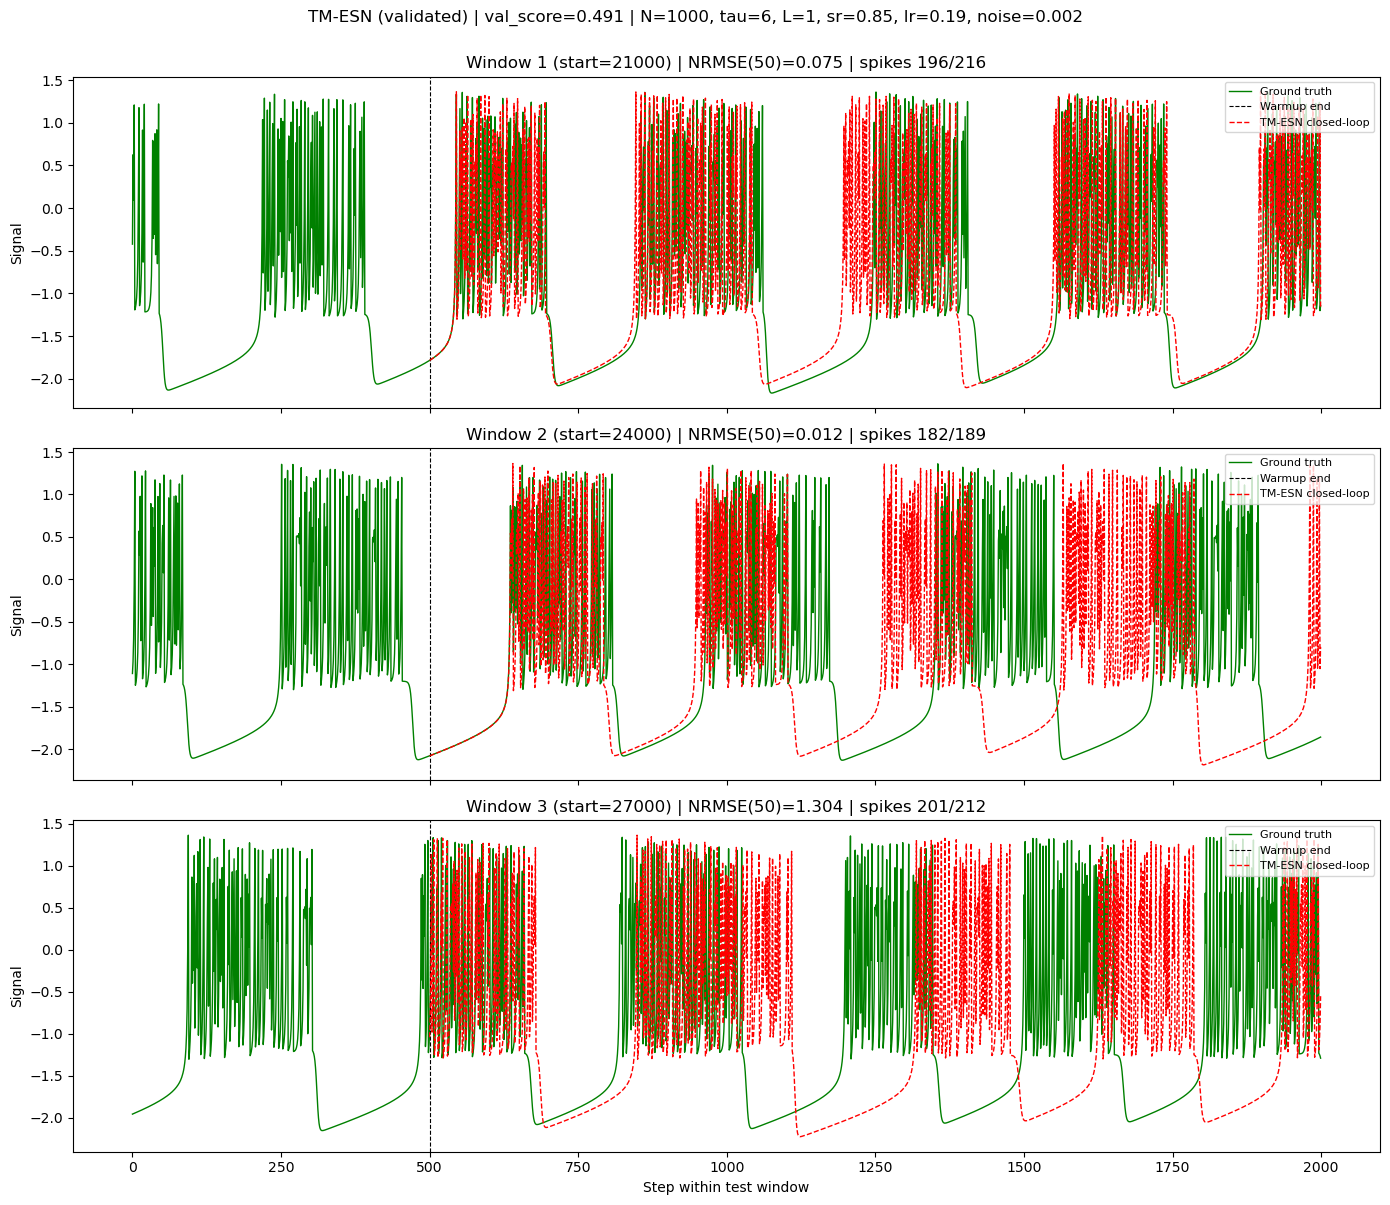

In [35]:
# This can be run either during the study or when it finishes
study.final_report()

In [ ]:
# Compare results between v1 and v2
import tm_esn_optuna as T

# Replace these with your actual v1 best params
v1_best_params = {
    "units": 1500,
    "connectivity": 0.05,
    "sr": 0.95,
    "lr": 0.4,
    "input_scaling": 1.0,
    "tau": 8,
    "L": 4,
    "noise_sigma": 0.005,
    # v1 didn't have bias_scaling — use the old fixed default of 0.5
    "bias_scaling": 0.5,
    "train_warmup": 500,
    "test_warmup": 500,
}

# Score it under v2's full evaluation
results = T.evaluate_arch(
    v1_best_params,
    T.RIDGE_VALUES,
    seeds=T.SEEDS_FINAL,
    X_train=T.X_train_full,
    Y_train=T.Y_train_full,
)
best_ridge, (score, nrmse_s, spike_p, isi_d) = min(
    results.items(), key=lambda kv: kv[1][0]
)
print(f"v1's winner re-scored under v2's metric:")
print(f"  Composite score: {score:.4f}")
print(f"  NRMSE_short:     {nrmse_s:.4f}")
print(f"  Spike penalty:   {spike_p:.4f}")
print(f"  ISI distance:    {isi_d:.4f}")
print(f"  Best ridge:      {best_ridge:.0e}")